## Parâmetros da Simulação

In [2]:
import os

os.environ.setdefault("NUMBA_DISABLE_COVERAGE", "1")

import numpy as np

from numba import jit

import time

from tqdm.notebook import tqdm



K = 512  # tamanho da chave

L = 412  # tamanho da tag e da mensagem

N = 10**3

rho_s = np.sqrt(0.985)  # alocação de potência para a mensagem

# relação snr em dB
snr_db = 10

# probabilidade de falso negativo
eta = 1e-7



# SNR de dB para valor linear para usar nas contas
SNR_LINEAR = 10 ** (snr_db / 10)

# variância base do ruído branco com base na SNR
SIGMA2W_BASE = 1.0 / SNR_LINEAR



## Mensagem e Modulação BPSK (Otimizado)

In [3]:
#função para gerar bits e modulá-los em BPSK
def modulator_bpsk(L, seed=None):
    """Modulação BPSK vetorizada"""
    # gera sementes aleatórias
    if seed is not None:
        np.random.seed(seed)
    # seleção de bits 0 ou 1 em forma de array usando dtype pequeno para economizar memória
    s_bin = np.random.randint(0, 2, size=L, dtype=np.int8)
    # Conversão dos bits para símbolos BPSK onde 0 vira +1 e 1 vira -1
    s_bpsk = 1 - 2 * s_bin  # mapeia 0->1, 1->-1
    # return tanto os bits originais quanto a forma modulada
    return s_bin, s_bpsk

## Geração das TAGs (Otimizado com Numba)

In [4]:
# constantes do polinômio quadrático 
A, B, C = 6, 1, 1


# tirei o @jit antigo porque fazer potência gigante estourava inteiro ao usar (2 ** K)
# Essa função aplica o polinômio e reduz o resultado módulo 2^K
def Mfunc_fast(x, K):
    return (A * x**2 + B * x + C) % (1 << K)


@jit(nopython=True)
# pré-cálculo de constantes no loop para substituir divisões repetidas
# geração da órbita da função logística com beta ajustável
def orbit_fast(x0, steps, beta=1e-6):
    # pré-alocação do array de saída para evitar realocações
    xorbit = np.empty(steps, dtype=np.float64)
    # começo da órbita com o valor inicial recebido
    x = x0
    # cálculo das constantes para o caso x < beta para evitar divisão repetida
    inv_beta_plus = 2.0 / (beta + 1)
    # cálculo das constantes para o caso x >= beta também
    inv_beta_minus = 2.0 / (beta - 1)
    # termo constante quando estamos abaixo de beta
    const_plus = (1 - beta) / (beta + 1)
    # termo constante quando estamos acima de beta
    const_minus = -(beta + 1) / (beta - 1)
    # loop da órbita guardando cada passo
    for i in range(steps):
        # se o ponto está abaixo de beta uso a equação positiva
        if x < beta:
            x = inv_beta_plus * x + const_plus
        else:
            # c.c aplico a outra transformação
            x = inv_beta_minus * x + const_minus
        # armazenamento do valor atualizado no array
        xorbit[i] = x
    # return de todo o vetor gerado
    return xorbit


# conversor bit a bit para evitar estouro de memória
def binary_to_int_fast(binary_array):
    # começa com o zero e vai acumulando bit a bit
    value = 0
    # percorrer cada bit e deslocar o valor anterior
    for bit in binary_array.tolist():
        value = (value << 1) | int(bit)
    # return do inteiro formado pelos bits
    return value


# aqui é gerada a tag caótica a partir da mensagem e da chave
def generate_tag(L, K, bits_msg, chave, x0=None):
    # sigma controla quantos valores da órbita descartamos
    sigma = K - L
    # se não recebo um ponto inicial uso o fluxo padrão
    if x0 is None:
        # mensagem para o tamanho da chave
        m_filled = np.resize(bits_msg, K)
        # XOR dos bits preenchidos com a chave
        s_xor_k = np.bitwise_xor(m_filled, chave)
        # vetor de bits em número inteiro gigante(função bit a bit criada)
        xor_value = binary_to_int_fast(s_xor_k)
        # Rodo o polinômio modulando por 2^K para gerar xi
        xi = Mfunc_fast(xor_value, K=K)
        # Normalizo xi para ficar no intervalo [-1, 1]
        x0_norm = (xi / (2 ** K - 1)) * 2 - 1
    else:
        # Se já recebo um ponto inicial uso ele direto
        x0_norm = x0
    # Gero toda a órbita e descarto os sigma primeiros pontos
    orb = orbit_fast(x0_norm, K)
    # Retorno apenas os últimos L valores como a tag
    return orb[sigma:]

In [5]:
# sorteio uma chave binária com K bits
chave = np.random.randint(0, 2, K, dtype=np.int8)
# mensagem aleatória e sua versão BPSK
bits_msg, bpsk_msg = modulator_bpsk(L)
# tag só para aquecer funções pesadas
_ = generate_tag(L, K, bits_msg, chave)
# tempo antes de gerar várias tags para medir desempenho
start = time.time()
# criação da tag várias vezes para medir média de tempo
for _ in range(100):
    tag = generate_tag(L, K, bits_msg, chave)
# tempo gasto e converto para milissegundos
elapsed_ms = (time.time() - start) * 1000
# quanto tempo levou produzir 100 tags
print(f"Tempo para 100 tags: {elapsed_ms:.2f} ms")
# média da tag para garantir que não saturou
print(f"Média da tag: {np.mean(tag):.6f}")
# variância da tag como sanity check
print(f"Variância da tag: {np.var(tag):.6f}")
# potência média só por curiosidade
print(f"Potência média: {np.mean(tag**2):.6f}")

Tempo para 100 tags: 10.89 ms
Média da tag: -0.012136
Variância da tag: 0.341774
Potência média: 0.341921


## Transmissão (Otimizado)

In [6]:
# Aceleração do cálculo de potência média da tag com Numba
@jit(nopython=True)
def compute_tag_power_fast(tag):
    # return da média dos quadrados que dá a potência
    return np.mean(tag**2)

# mix mensagem e tag com pesos baseados em rho_s
def combine_message_tag(s, tag, rho_s):
    # potência da tag para saber o peso ideal
    Ptag = compute_tag_power_fast(tag)
    # ganho da tag para manter a soma unitária
    rho_t = np.sqrt((1 - rho_s**2) / Ptag)
    # combinação linear dos sinais
    x = rho_s * s + rho_t * tag
    # return do sinal combinado e o ganho usado
    return x, rho_t

# Gero ruído branco gaussiano com base na SNR
def gen_noise_fast(snr_db, length):
    # Como SIGMA2W_BASE já guarda a variância, apenas reutilizo
    sigma2w = SIGMA2W_BASE
    # Gero ruído normal com média zero e variância sigma2w
    noise = np.random.normal(0, np.sqrt(sigma2w), length)
    # Retorno a variância e o vetor de ruído
    return sigma2w, noise

# adição de ruído AWGN no sinal transmitido
def add_awgn(x, snr_db):
    # reaproveito a função de ruído para ter sigma e amostras
    sigma2w, noise = gen_noise_fast(snr_db, len(x))
    # adição do ruído ao sinal original
    y = x + noise
    # return do sinal ruidoso e o ruído gerado
    return y, noise

## Recepção (Otimizado)

In [7]:
# Numba para acelerar a estatística de decisão
@jit(nopython=True)
def detect_tag_fast(y, s, t_ref, rho_s, rho_t):
    # acumulador em zero
    stat = 0.0
    # cada amostra recebida
    for i in range(len(y)):
        # contribuição da mensagem e normalizo pela tag
        y_minus_msg = (y[i] - rho_s * s[i]) / rho_t
        # acumulo o produto com a tag de referência
        stat += y_minus_msg * t_ref[i]
    # return do valor final da estatística
    return stat

## Limiar de Decisão (Otimizado)

In [8]:
# erfc da math porque funciona com Numba em modo nopython
from math import erfc
# nesta versão usamos math.erfc no lugar de scipy.special.erfc para manter o JIT nopython
# import da distribuição normal da scipy para pegar o ppf
from scipy.stats import norm


# função Q usando erfc para trabalhar com probabilidades caudais
@jit(nopython=True)
def Qfunc_fast(x):
    # fórmula Q = 0.5 * erfc(x / sqrt(2)) evita problemas de precisão
    return 0.5 * erfc(x / np.sqrt(2))


# limiar ótimo usando o inverso da normal
def thresh_optimized(std_dev, mean, alpha):
    # norm.ppf nos dá o valor que deixa alpha de área na cauda
    return norm.ppf(1 - alpha, loc=mean, scale=std_dev)


# variância da estatística tau calculada com ajuda do ganho
@jit(nopython=True)
def tauVarCalc_fast(sigma2w, length, rho_t, sigma2tag):
    # fórmula derivada da propagação de variâncias das tags
    return (sigma2tag * sigma2w * length) / (rho_t ** 2)


# Substituímos o laço incremental antigo e usamos o ppf fechado
# Calcula o limiar de decisão com base na variância estimada
def threshold_decision(sigma2w, length, rho_t, tag, eta):
    # Pegamos a variância da tag observado na simulação
    sigma2tag = np.var(tag)
    # Calculamos a variância da estatística de teste
    sigma2_v = tauVarCalc_fast(sigma2w, length, rho_t, sigma2tag)
    # Usamos o limiar teórico direto para alcançar a meta eta
    return thresh_optimized(np.sqrt(sigma2_v), 0.0, eta)

## Matriz de Confusão

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# função que calcula e plota a matriz de confusão
def compute_confusion_matrix(stat_H1, stat_H0, tau):
    # os rótulos verdadeiros: 1 para H1 e 0 para H0
    y_true = np.concatenate([np.ones(len(stat_H1)), np.zeros(len(stat_H0))])
    # cola das estatísticas para comparar com o limiar
    y_scores = np.concatenate([stat_H1, stat_H0])
    # se o limiar for escalar, replicamos para todos os pontos
    if np.isscalar(tau):
        tau_vec = np.full_like(y_scores, tau, dtype=float)
    else:
        # cc, criamos um vetor alinhado com os scores
        tau_vec = np.array([tau[i % len(tau)] for i in range(len(y_scores))])
    # decidimos H1 quando o score passa do limiar
    y_pred = (y_scores >= tau_vec).astype(int)
    # Calculamos a matriz de confusão usando a função do sklearn
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    # desembrulhamos os valores TN, FP, FN, TP
    TN, FP, FN, TP = cm.ravel()
    # normalizamos pela quantidade de amostras H0 para comparação justa
    cm_normalized = cm.astype(float) / len(stat_H0)
    # mostramos métricas principais para acompanhar qualidade
    print(f"TP: {TP/len(stat_H1):.3f}, FP: {FP/len(stat_H0):.3f}, TN: {TN/len(stat_H0):.3f}, FN: {FN/len(stat_H1):.3f}")
    # acurácia total
    print(f"Accuracy: {(TP + TN) / len(y_true):.3f}")
    # taxa de falso positivo
    print(f"False Positive Rate: {FP/len(stat_H0):.3f}")
    # taxa de falso negativo
    print(f"False Negative Rate: {FN/len(stat_H1):.3f}")
    # objeto de visualização com a matriz normalizada
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['H0', 'H1'])
    # figura com a colormap azul
    disp.plot(cmap='Blues')
    # grid clean
    plt.grid(False)
    # título indicando que é matriz de confusão
    plt.title('Matriz de Confusão')
    # gráfico na tela
    plt.show()

## Teste de Hipótese (Otimizado)

In [10]:
# vetores no lugar de listas com append para reduzir realocações
def simulate_hypothesis_test(L, K, N, rho_s, snr_db, chave, sigma2w, eta):
    # espaço para guardar as estatísticas quando a tag está presente
    all_stat_H1 = np.zeros(N, dtype=np.float64)
    # espaço para estatísticas quando a tag não está presente
    all_stat_H0 = np.zeros(N, dtype=np.float64)
    # espaço para os limiares individuais
    tau_vec = np.zeros(N, dtype=np.float64)
    # N execuções independentes
    for n in range(N):
        # uma nova mensagem modulada
        bits_msg, bpsk_msg = modulator_bpsk(L)
        # a tag legítima usando a chave e a mensagem
        tag_legit = generate_tag(L, K, bits_msg, chave)
        # combina mensagem e tag com as potências certas
        x_tag, rho_t = combine_message_tag(bpsk_msg, tag_legit, rho_s)
        # adiciona ruído e obtenho o sinal recebido sob H1
        y_legit, _ = add_awgn(x_tag, snr_db)
        # calcula a estatística quando a tag existe
        tau_H1 = detect_tag_fast(y_legit, bpsk_msg, tag_legit, rho_s, rho_t)
        # gera o sinal falso sem tag mas com mesmo ruído
        y_fake, _ = add_awgn(bpsk_msg, snr_db)
        # calcula a estatística quando não há tag
        tau_H0 = detect_tag_fast(y_fake, bpsk_msg, tag_legit, rho_s, rho_t)
        # calcula o limiar ótimo baseado na tag observada
        tau_i = threshold_decision(sigma2w, L, rho_t, tag_legit, eta)
        # salva o valor de H1 no vetor final
        all_stat_H1[n] = tau_H1
        # salva o valor de H0 no vetor final
        all_stat_H0[n] = tau_H0
        # salva o limiar da rodada
        tau_vec[n] = tau_i
    # return dos três vetores preenchidos
    return all_stat_H1, all_stat_H0, tau_vec

## Threshold Empírico Otimizado

In [11]:
# procura um limiar empírico que respeite a taxa de falso positivo desejada
def find_threshold_to_reduce_fp(stat_H1, stat_H0, eta):
    # junta todas as estatísticas e ordeno para testar como limiar
    all_scores = np.sort(np.concatenate([stat_H1, stat_H0]))
    # Calcula a taxa de falso positivo para cada possível limiar
    fp_rates = np.array([np.sum(stat_H0 >= tau) / len(stat_H0) for tau in all_scores])
    # pega os índices onde a taxa cai abaixo ou igual ao alvo
    valid_idx = np.where(fp_rates <= eta)[0]
    # se nenhum limiar respeita o alvo, devolvo None
    if len(valid_idx) == 0:
        return None
    # c.c, retorno o primeiro limiar válido
    return all_scores[valid_idx[0]]

## Histogramas

In [12]:
# plota as distribuições teóricas da estatística
def plot_histograma_teorico(L, N, snr_db, eta, rho_s):
    # estima rho_t assumindo tag com potência média 1/3
    rho_t = np.sqrt((1 - rho_s**2) * 3)
    # converte SNR para base 10
    SNR = 10 ** (snr_db / 10)
    # variância teórica da tag considerada
    sigma2tag = 1 / 3
    # variância da estatística sob H0 com base em derivação teórica
    sigma2v = (sigma2tag * L) / (SNR * rho_t**2)
    # uso do limiar teórico
    tau = thresh_optimized(np.sqrt(sigma2v), 0, eta)
    # média da estatística sob H0 é zero
    mu_H0 = 0
    # média considerando energia da tag(H1)
    mu_H1 = L / 3
    # limites do gráfico
    min_val = min(mu_H0 - 4 * np.sqrt(sigma2v), mu_H1 - 4 * np.sqrt(sigma2v))
    max_val = max(mu_H0 + 4 * np.sqrt(sigma2v), mu_H1 + 4 * np.sqrt(sigma2v))
    # pontos para a curva contínua
    x = np.linspace(min_val, max_val, N)
    # PDF sob H0 com média zero
    pdf_H0 = norm.pdf(x, loc=mu_H0, scale=np.sqrt(sigma2v))
    # PDF sob H1 com média deslocada
    pdf_H1 = norm.pdf(x, loc=mu_H1, scale=np.sqrt(sigma2v))
    # Abro figura com tamanho confortável
    plt.figure(figsize=(8, 5))
    # curva H0 em azul
    plt.plot(x, pdf_H0, label='τ|H₀ (Sem Tag)', color='tab:blue', linewidth=2)
    # curva H1 em laranja
    plt.plot(x, pdf_H1, label='τ|H₁ (Com TAG)', color='tab:orange', linewidth=2)
    # se o limiar existe, desenho as linhas verticais de referência
    if tau is not None:
        plt.axvline(tau, color='red', linestyle='--', linewidth=2, label=f'τ = {tau:.3f}')
        plt.axvline(mu_H1, color='green', linestyle='--', linewidth=2, label=f'E(τ|H1) = {mu_H1:.3f}')
        plt.axvline(mu_H0, color='yellow', linestyle='--', linewidth=2, label=f'E(τ|H0) = {mu_H0:.3f}')
    # título e rótulos
    plt.title('Distribuições Teóricas de τ sob H₀ e H₁')
    plt.xlabel('Estatística do teste (τᵢ)')
    plt.ylabel('P(τ)')
    # legendas e grid suave
    plt.legend()
    plt.grid(alpha=0.3)
    # layout arrumado
    plt.tight_layout()
    # gráfico
    plt.show()

# plota histograma baseado em simulação Monte Carlo
def plot_histograma_MonteCarlo(K, N, snr_db, eta, rho_s):
    # ruído para ter sigma2w consistente
    sigma2w, _ = gen_noise_fast(snr_db, K - 32)
    # sorteio uma chave aleatória
    chave = np.random.randint(0, 2, K, dtype=np.int8)
    # simulação para obter as estatísticas das duas hipóteses
    stat_H1, stat_H0, threshold = simulate_hypothesis_test(K - 32, K, N, rho_s, snr_db, chave, sigma2w, eta)
    # figura para os histogramas
    plt.figure(figsize=(8, 5))
    # histograma para H0 em azul
    plt.hist(stat_H0, bins=40, alpha=0.6, label='τ|H₀ (Sem Tag)', color='tab:blue', density=True)
    # histograma para H1 em laranja
    plt.hist(stat_H1, bins=40, alpha=0.6, label='τ|H₁ (Com TAG)', color='tab:orange', density=True)
    # linha vertical com o limiar médio encontrado
    plt.axvline(np.mean(threshold), color='red', linestyle='--', linewidth=2, label=f'τ = {np.mean(threshold):.3f}')
    # linha com a média de H1 para comparação
    plt.axvline(np.mean(stat_H1), color='green', linestyle='--', linewidth=2, label=f'E(τ|H1) = {np.mean(stat_H1):.3f}')
    # linha com a média de H0
    plt.axvline(np.mean(stat_H0), color='yellow', linestyle='--', linewidth=2, label=f'E(τ|H0) = {np.mean(stat_H0):.3f}')
    # título, eixos e legenda
    plt.title('Distribuições de Estatísticas sob H₀ e H₁')
    plt.xlabel('Estatística do teste (τᵢ)')
    plt.ylabel('P(τ)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Teste de Performance e Visualização

Gerando histogramas...


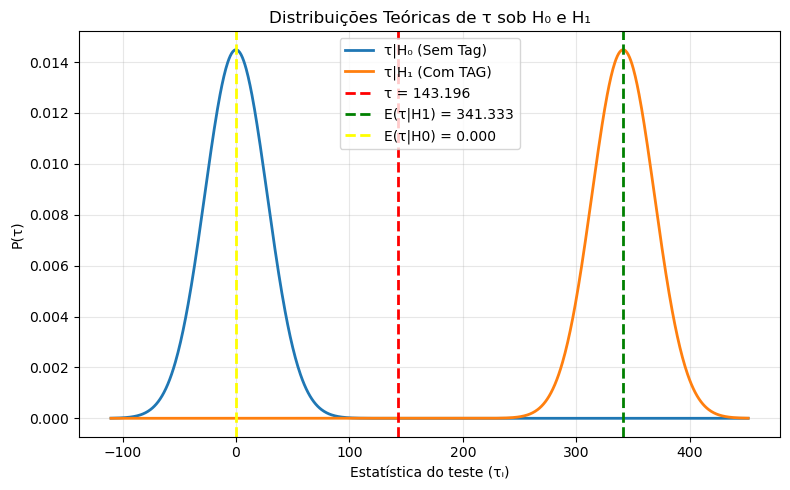

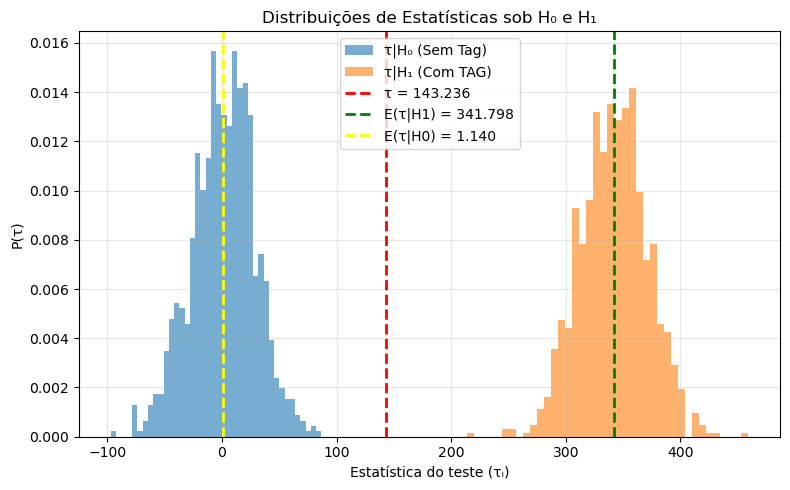

In [13]:
print('Gerando histogramas...')
# chama a função teórica com parâmetros padrão do estudo
plot_histograma_teorico(1024, 1000, 10, 1e-7, np.sqrt(0.985))
# chama a versão Monte Carlo para comparar com o teórico
plot_histograma_MonteCarlo(1056, 1000, 10, 1e-7, np.sqrt(0.985))

## Trade-offs: FNR vs L (Otimizado)

In [14]:
# calculo da probabilidade de falso negativo teórica variando L
def fnr_vs_L_theoretical(K, N, snr_db, eta, rho_s):
    # rho_t assumindo mesma potência média que antes
    rho_t = np.sqrt((1 - rho_s**2) * 3)
    # snr para escala linear
    SNR = 10 ** (snr_db / 10)
    # maior L possível(igual ao tamanho da chave)
    L_max = K
    # gera os valores de L que vamos testar
    L_values = range(32, L_max, 32)
    # reserva lista para guardar probabilidades
    fnr_prob = []
    # tqdm para acompanhar o progresso da parte teórica
    for L in tqdm(L_values, desc='FNR Teórico'):
        # acumulador de probabilidade de falso negativo para esse L
        prob = 0.0
        # arrays_temp para armazenar estatísticas e variâncias
        tau_H1 = np.zeros(N, dtype=np.float64)
        variancias = np.zeros(N, dtype=np.float64)
        # repetição de 50 blocos para estabilizar as médias
        for _ in range(50):
            # para cada teste dentro do bloco é gerada uma nova chave
            for n in range(N):
                chave = np.random.randint(0, 2, L + 32, dtype=np.int8)
                # geração da mensagem e sua versão BPSK
                bits_msg, _ = modulator_bpsk(L)
                # tag correspondente à mensagem e chave
                tag = generate_tag(L, L + 32, bits_msg, chave)
                # Energia acumulada da tag para H1
                tau_H1[n] = np.sum(tag**2)
                # armazenamento da variância da tag
                variancias[n] = np.var(tag)
            # cálculo da média das variâncias para o bloco
            sigma2tag = np.mean(variancias)
            # cálculo da variância da estatística tau usando a fórmula teórica
            sigma2v = (sigma2tag * L) / (SNR * rho_t**2)
            # valor teórico do limiar para esse bloco
            tau = thresh_optimized(np.sqrt(sigma2v), 0, eta)
            # aproximação da probabilidade de FN usando a função Qfunc
            prob += (1 - Qfunc_fast((tau - np.mean(tau_H1)) / np.sqrt(sigma2v))) / 50
        # depois dos 50 blocos, armazena o resultado para esse L
        fnr_prob.append(prob)
    # return da lista com os valores de cada L
    return fnr_prob

# calcula a probabilidade de falso negativo via simulação Monte Carlo
def fnr_vs_L_MonteCarlo(K, N, snr_db, eta, rho_s):
    # limite máximo de L igual ao tamanho da chave
    L_max = K
    # gera a lista de comprimentos testados
    L_values = range(32, L_max, 32)
    # reserva lista onde ficará o FNR por L
    fnr_values = []
    # Loop principal com barra de progresso
    for L in tqdm(L_values, desc='FNR Monte Carlo'):
        # acumulador de falso negativo para esse L
        fnr = 0.0
        # repetição de 50 blocos para obter uma média estável
        for _ in range(50):
            # geroção de uma chave aleatória do tamanho definido
            chave = np.random.randint(0, 2, L + 32, dtype=np.int8)
            # geração de ruído -> obtenho sigma2w
            sigma2w, _ = gen_noise_fast(snr_db, L)
            # calculo da simulação completa para pegar estatísticas
            stat_H1, stat_H0, thresh_vec = simulate_hypothesis_test(L, L + 32, N, rho_s, snr_db, chave, sigma2w, eta)
            # verdadeiros
            y_true = np.concatenate([np.ones(len(stat_H1)), np.zeros(len(stat_H0))])
            # concatenaçaõ das estatísticas das duas hipóteses
            y_scores = np.concatenate([stat_H1, stat_H0])
            # se necessário, replico os limiares para cada score
            tau_vec = np.array([thresh_vec[i % len(thresh_vec)] for i in range(len(y_scores))])
            # gera decisões comparando com o limiar
            y_pred = (y_scores >= tau_vec).astype(int)
            # cálcula a matriz de confusão para contar falsos negativos
            cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
            # desempacota os valores TN, FP, FN, TP
            TN, FP, FN, TP = cm.ravel()
            # acumulo de falso negativo normalizado
            fnr += (FN / len(stat_H1)) / 50
        # armazenar fnr depois de n iterações
        fnr_values.append(fnr)
    # return da lista completa
    return fnr_values

## Execução e Salvamento de Resultados

In [15]:
# inicio dos cálculos de maior complexidade, mas com as otimizações implementadas(teste).
print('Iniciando cálculos otimizados(teste)...')
# t_0 parte teórica
start_time = time.time()
# calculo das probabilidades teóricas para vários L
auth_prob = fnr_vs_L_theoretical(512, 10**3, 10, 1e-7, np.sqrt(0.985))
# save dos resultados, teóricos, em arquivo no formato NPZ
np.savez('fnr_teorico_2.npz', auth_prob=auth_prob)
# tempo da parte teórica(rápido)
print(f'Tempo teórico: {time.time() - start_time:.2f}s')
# t_0 monte carlo
start_time = time.time()
# Calculo o FNR
fnr_values = fnr_vs_L_MonteCarlo(512, 10**3, 10, 1e-7, np.sqrt(0.985))
# save dos resultados em arquivo no formato NPZ
np.savez('fnr_MonteCarlo_2.npz', fnr_values=fnr_values)
# timing de simulação
print(f'Tempo Monte Carlo: {time.time() - start_time:.2f}s')

Iniciando cálculos otimizados(teste)...


FNR Teórico:   0%|          | 0/15 [00:00<?, ?it/s]

Tempo teórico: 142.11s


FNR Monte Carlo:   0%|          | 0/15 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Visualização Final

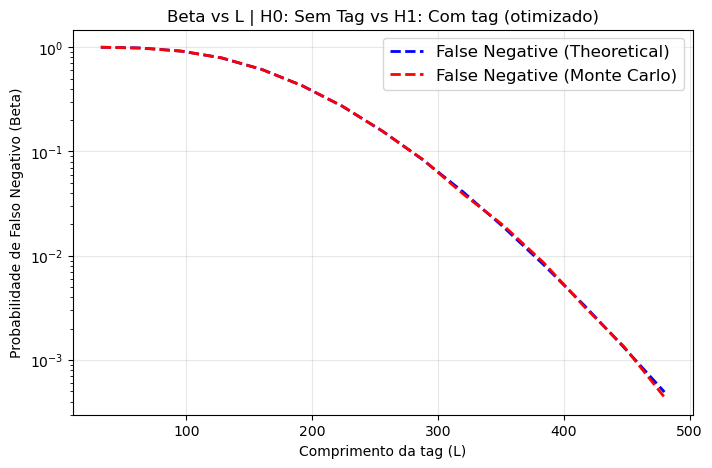

In [ ]:
# eixo das curvas na mesma escala
L_values = range(32, 512, 32)
# load dos resultados teóricos
auth_prob = np.load('fnr_teorico_2.npz')['auth_prob']
# resultados armazenados Monte Carlo
fnr_values = np.load('fnr_MonteCarlo_2.npz')['fnr_values']
# compração das curvas
plt.figure(figsize=(8, 5))
# plot da curva teórica em escala logarítmica
plt.semilogy(L_values, auth_prob, '--b', linewidth=2, label='False Negative (Theoretical)')
# plot da curva Monte Carlo também em log
plt.semilogy(L_values, fnr_values, '--r', linewidth=2, label='False Negative (Monte Carlo)')
# configuração dos rótulos
plt.xlabel('Comprimento da tag (L)')
plt.ylabel('Probabilidade de Falso Negativo (Beta)')
# título
plt.title('Beta vs L | H0: Sem Tag vs H1: Com tag (otimizado)')
# coloco legenda para diferenciar as curvas
plt.legend(loc='best', fontsize=12, frameon=True)
# grid
plt.grid(True, alpha=0.3)
# gráfico
plt.show()